# Analysis of Factors Influencing Airline Ticket Prices

This project investigates the factors associated with average airline fares and evaluates the ability of statistical and machine learning models to predict fares using market-, route-, carrier-, and competition-related characteristics.

The analysis uses the **Airline Market Fare Prediction Data** dataset developed by K. Gülnaz Bülbül from publicly available U.S. Bureau of Transportation Statistics (BTS) data.

**Research objective**

The analysis addresses two related questions:

1. Which market, route, carrier, and competition-related factors are associated with average airline fares?
2. How accurately can statistical and machine learning regression models predict average fares?

The workflow includes exploratory data analysis, feature assessment, regression modeling, ensemble methods, model comparison, feature importance, and robustness analysis.

> This project uses publicly available market-level data. It does not contain confidential or proprietary data from Azerbaijan Airlines or any other airline.

## 1. Setup

This section imports the libraries used for data manipulation and visualization, defines reproducibility settings, and establishes the project paths used throughout the notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42

TARGET = "Average_Fare"
MODELING_SAMPLE_SIZE = 200_000

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "MarketFarePredictionData.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Project root: c:\Users\eldar\Desktop\portfolio\python\Analysis of Factors Influencing Airline Ticket Prices Using Statistical and Machine Learning Methods
Dataset path: c:\Users\eldar\Desktop\portfolio\python\Analysis of Factors Influencing Airline Ticket Prices Using Statistical and Machine Learning Methods\data\MarketFarePredictionData.csv


## 2. Data Loading and Validation

The dataset contains airline market observations constructed from the DB1B and T-100 datasets provided by the U.S. Bureau of Transportation Statistics. The processed dataset contains 26 variables covering route characteristics, passenger volumes, carrier activity, market concentration, competition, and average fares.

Before analysis, the dataset structure is validated to ensure that the expected variables are available.

In [5]:
EXPECTED_COLUMNS = [
    "MktCoupons",
    "OriginCityMarketID",
    "DestCityMarketID",
    "OriginAirportID",
    "DestAirportID",
    "Carrier",
    "NonStopMiles",
    "RoundTrip",
    "ODPairID",
    "Pax",
    "CarrierPax",
    "Average_Fare",
    "Market_share",
    "Market_HHI",
    "LCC_Comp",
    "Multi_Airport",
    "Circuity",
    "Slot",
    "Non_Stop",
    "MktMilesFlown",
    "OriginCityMarketID_freq",
    "DestCityMarketID_freq",
    "OriginAirportID_freq",
    "DestAirportID_freq",
    "Carrier_freq",
    "ODPairID_freq",
]

In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Download it using the instructions in data/README.md."
    )

df = pd.read_csv(DATA_PATH)

missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
unexpected_columns = sorted(set(df.columns) - set(EXPECTED_COLUMNS))

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

if unexpected_columns:
    print(f"Unexpected columns detected: {unexpected_columns}")

Dataset loaded: 1,581,278 rows × 26 columns


In [7]:
dataset_overview = pd.Series(
    {
        "Rows": f"{len(df):,}",
        "Columns": df.shape[1],
        "Memory usage (MB)": f"{df.memory_usage(deep=True).sum() / 1024**2:,.1f}",
        "Target": TARGET,
    },
    name="Value",
)

display(dataset_overview.to_frame())
display(df.head())

,Value
Rows,"1,581,278"
Columns,26
Memory usage (MB),313.7
Target,Average_Fare


,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,CarrierPax,Average_Fare,Market_share,Market_HHI,LCC_Comp,Multi_Airport,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
0,2,178,152,170,255,6,"1,807.0000",1.0000,4035,136.0000,96.0000,389.1000,0.7059,"5,847.7500",1,1,1.3675,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0220,0.1168,0.0001
1,2,178,152,170,194,20,"1,798.0000",1.0000,4035,136.0000,40.0000,283.3200,0.2941,"5,847.7500",1,1,1.0517,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0084,0.3077,0.0001
2,2,178,152,170,260,6,"1,784.0000",0.0000,4035,136.0000,96.0000,389.1000,0.7059,"5,847.7500",1,1,1.0348,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0094,0.1168,0.0001
3,2,178,152,170,255,6,"1,807.0000",1.0000,4035,136.0000,96.0000,389.1000,0.7059,"5,847.7500",1,1,1.0299,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0220,0.1168,0.0001
4,2,178,152,170,194,20,"1,798.0000",1.0000,4035,136.0000,40.0000,283.3200,0.2941,"5,847.7500",1,1,1.0623,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0084,0.3077,0.0001


## 3. Data Quality Assessment

Before exploring relationships in the data, basic quality checks are performed to identify missing values, exact duplicate rows, and structural issues that could affect subsequent analysis.

The dataset also contains several numerical identifiers. Although these columns are stored as integers, their values represent categories rather than continuous quantities. They are therefore separated from economically interpretable numerical features during exploratory correlation analysis.

In [8]:
IDENTIFIER_COLUMNS = [
    "OriginCityMarketID",
    "DestCityMarketID",
    "OriginAirportID",
    "DestAirportID",
    "Carrier",
    "ODPairID",
]

FREQUENCY_COLUMNS = [
    "OriginCityMarketID_freq",
    "DestCityMarketID_freq",
    "OriginAirportID_freq",
    "DestAirportID_freq",
    "Carrier_freq",
    "ODPairID_freq",
]

BINARY_FEATURES = [
    "RoundTrip",
    "LCC_Comp",
    "Multi_Airport",
    "Slot",
    "Non_Stop",
]

INTERPRETABLE_NUMERIC_FEATURES = [
    "MktCoupons",
    "NonStopMiles",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "Circuity",
    "MktMilesFlown",
    *BINARY_FEATURES,
]

In [9]:
quality_summary = pd.Series(
    {
        "Rows": len(df),
        "Columns": df.shape[1],
        "Missing values": int(df.isna().sum().sum()),
        "Duplicate rows": int(df.duplicated().sum()),
    },
    name="Value",
)

display(quality_summary.to_frame())

,Value
Rows,1581278
Columns,26
Missing values,0
Duplicate rows,1517905


### Descriptive Statistics

The summary below focuses on variables with direct analytical interpretations rather than encoded identifiers.

In [10]:
summary_columns = [
    TARGET,
    "NonStopMiles",
    "MktMilesFlown",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "Circuity",
]

display(
    df[summary_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Average_Fare,"1,581,278.0000",214.4831,73.3732,67.3900,166.9400,202.2700,246.6400,"1,265.9900"
NonStopMiles,"1,581,278.0000","1,183.1578",713.6535,100.0000,643.0000,"1,011.0000","1,590.0000","5,095.0000"
MktMilesFlown,"1,581,278.0000","1,213.7171",726.8271,102.0000,658.0258,"1,040.6415","1,639.1057","5,096.5207"
Pax,"1,581,278.0000","177,320.2494","238,028.8731",1.0000,"31,824.0000","86,543.0000","231,821.0000","1,495,396.0000"
CarrierPax,"1,581,278.0000","62,992.7908","88,025.5432",1.0000,"13,052.0000","31,068.0000","75,970.0000","706,835.0000"
Market_share,"1,581,278.0000",0.4872,0.2978,0.0500,0.2367,0.4273,0.7171,1.0000
Market_HHI,"1,581,278.0000","5,012.6265","2,494.3425","1,553.4200","3,057.0600","4,269.8200","6,339.9100","10,000.0000"
Circuity,"1,581,278.0000",1.0264,0.1092,1.0000,1.0000,1.0000,1.0000,2.9858


## 4. Target Variable Analysis

The prediction target is `Average_Fare`, representing the average fare associated with each market-carrier observation.

Its distribution is examined before modeling because substantial skewness and extreme values can affect regression performance and error metrics.

In [11]:
target_summary = pd.Series(
    {
        "Count": df[TARGET].count(),
        "Mean": df[TARGET].mean(),
        "Median": df[TARGET].median(),
        "Standard deviation": df[TARGET].std(),
        "Minimum": df[TARGET].min(),
        "Maximum": df[TARGET].max(),
        "Skewness": df[TARGET].skew(),
        "Excess kurtosis": df[TARGET].kurt(),
    },
    name="Value",
)

display(target_summary.to_frame())

,Value
Count,"1,581,278.0000"
Mean,214.4831
Median,202.2700
Standard deviation,73.3732
Minimum,67.3900
Maximum,"1,265.9900"
Skewness,2.4965
Excess kurtosis,15.5403


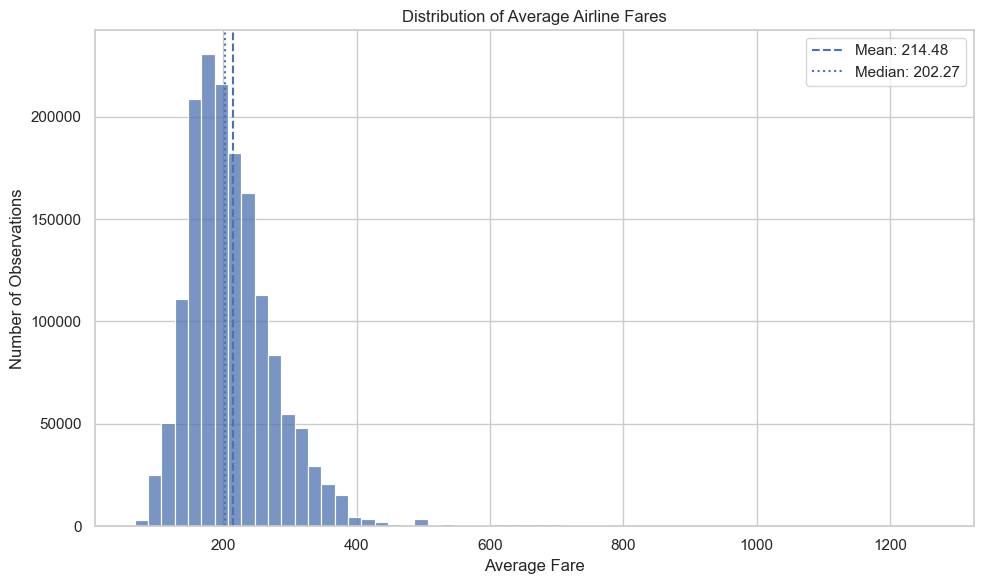

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x=TARGET,
    bins=60,
    ax=ax,
)

ax.axvline(
    df[TARGET].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {df[TARGET].mean():.2f}",
)

ax.axvline(
    df[TARGET].median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median: {df[TARGET].median():.2f}",
)

ax.set_title("Distribution of Average Airline Fares")
ax.set_xlabel("Average Fare")
ax.set_ylabel("Number of Observations")
ax.legend()

plt.tight_layout()
plt.show()

The target distribution is strongly right-skewed. The mean fare is approximately 214.48, compared with a median of approximately 202.27, while the maximum fare is substantially higher at 1,265.99.

The calculated skewness of approximately 2.50 and excess kurtosis of approximately 15.54 confirm a long right tail and a higher concentration of extreme values than would be expected under a normal distribution.

These characteristics motivate the use of both MAE and RMSE during model evaluation: MAE provides an interpretable measure of typical absolute prediction error, while RMSE places greater weight on larger errors.

## 5. Correlation Analysis

Pearson correlations are examined for variables with meaningful numerical interpretations.

Encoded identifiers such as carrier, airport, market, and origin-destination IDs are intentionally excluded. Although stored numerically, the differences between their integer values do not represent meaningful quantitative differences.

Frequency-encoded identifiers are also excluded from this descriptive correlation analysis because their interpretation differs from the underlying economic and route characteristics.

In [13]:
correlation_features = [
    TARGET,
    *INTERPRETABLE_NUMERIC_FEATURES,
]

correlation_matrix = df[correlation_features].corr()

target_correlations = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .rename("Correlation")
    .to_frame()
)

display(target_correlations)

,Correlation
NonStopMiles,0.7348
MktMilesFlown,0.7346
Market_HHI,0.2529
Market_share,0.2420
MktCoupons,0.2169
Non_Stop,-0.2140
LCC_Comp,-0.1726
Pax,-0.1618
CarrierPax,-0.1043
Circuity,0.0352


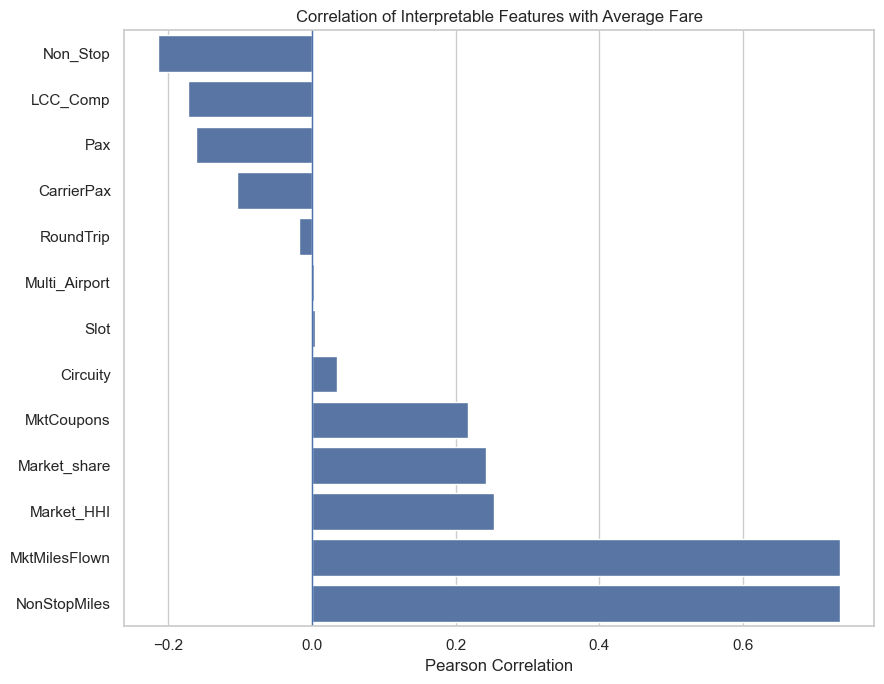

In [14]:
correlation_plot = (
    target_correlations
    .reset_index()
    .rename(columns={"index": "Feature"})
    .sort_values("Correlation")
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    data=correlation_plot,
    x="Correlation",
    y="Feature",
    ax=ax,
)

ax.axvline(0, linewidth=1)
ax.set_title("Correlation of Interpretable Features with Average Fare")
ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Distance-related variables show the strongest positive linear associations with average fares. `NonStopMiles` and `MktMilesFlown` both have correlations of approximately 0.73 with the target, indicating that longer markets generally exhibit higher average fares.

Market concentration (`Market_HHI`) and carrier market share (`Market_share`) show more moderate positive relationships of approximately 0.25 and 0.24, respectively.

These correlations describe association rather than causation. They also do not account for interactions among predictors or nonlinear relationships, which are examined later using machine learning models.

### Relationships Among Continuous Predictors

A reduced correlation matrix is used to examine relationships among the main continuous explanatory variables. This is particularly relevant for identifying strongly related predictors before estimating linear and regularized regression models.

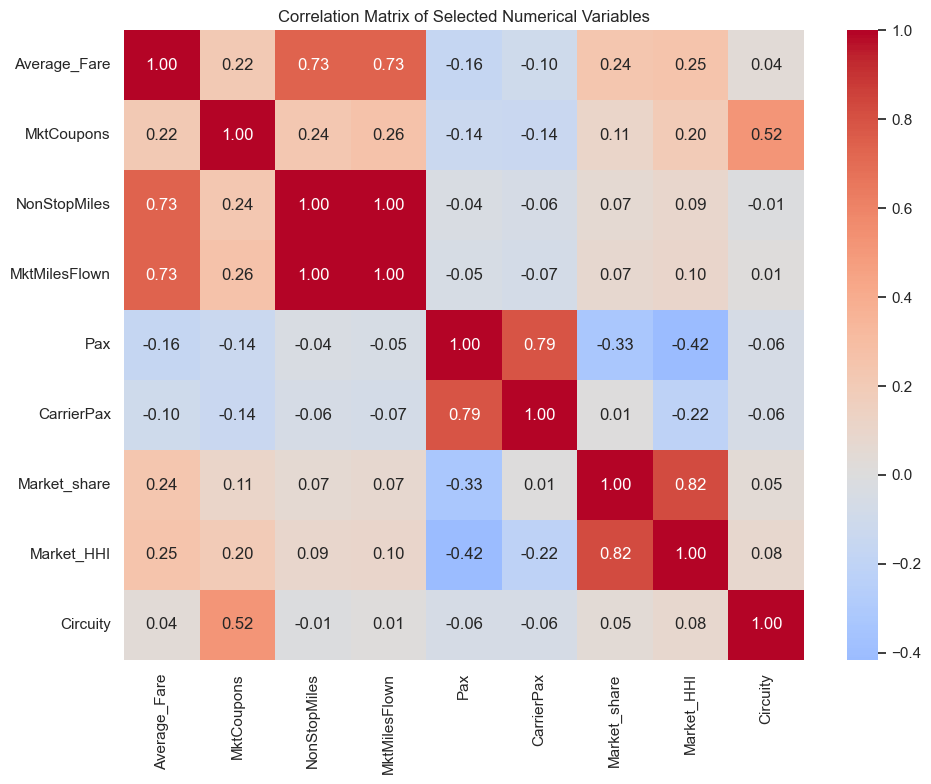

In [15]:
heatmap_features = [
    TARGET,
    "MktCoupons",
    "NonStopMiles",
    "MktMilesFlown",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "Circuity",
]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)

ax.set_title("Correlation Matrix of Selected Numerical Variables")

plt.tight_layout()
plt.show()

## 6. Relationships with Average Fare

Because the dataset contains more than 1.5 million observations, plotting every row would create substantial overplotting and unnecessary rendering cost. A reproducible random sample is therefore used for visualization only.

All descriptive statistics and model inputs remain based on the datasets explicitly stated in their respective sections.

In [16]:
EDA_SAMPLE_SIZE = 50_000

eda_sample = df.sample(
    n=min(EDA_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE,
)

print(f"Visualization sample: {len(eda_sample):,} observations")

Visualization sample: 50,000 observations


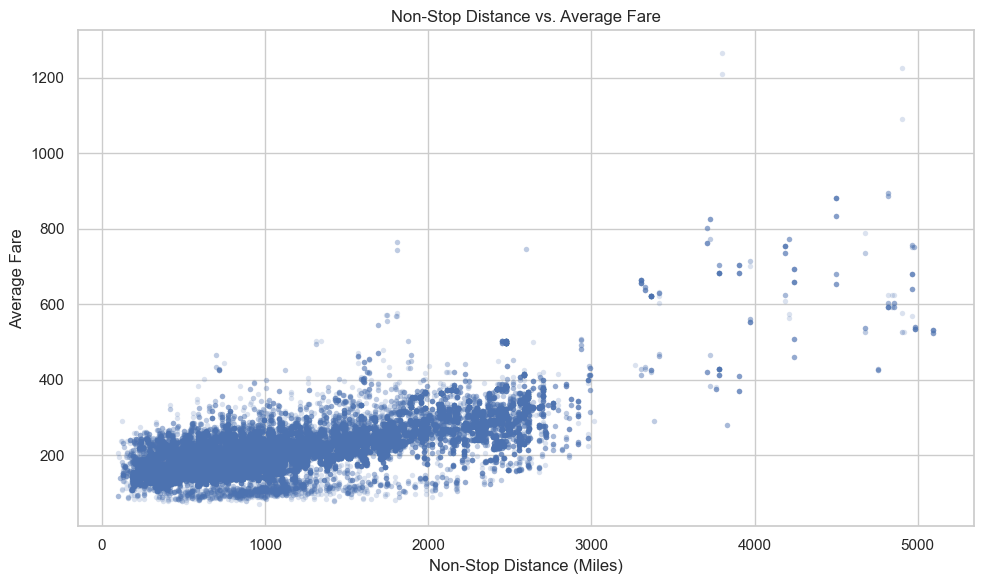

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="NonStopMiles",
    y=TARGET,
    alpha=0.2,
    s=15,
    linewidth=0,
    ax=ax,
)

ax.set_title("Non-Stop Distance vs. Average Fare")
ax.set_xlabel("Non-Stop Distance (Miles)")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

The scatter plot supports the correlation analysis: fares generally increase with route distance, although substantial variation remains at similar distances. This indicates that distance is important but insufficient on its own to explain fare differences.

### Market Concentration

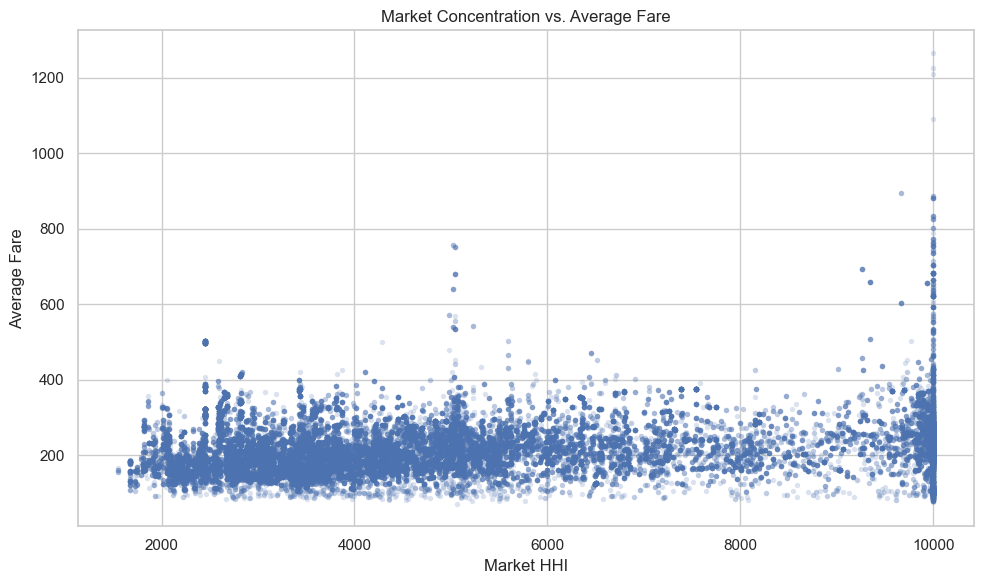

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="Market_HHI",
    y=TARGET,
    alpha=0.2,
    s=15,
    linewidth=0,
    ax=ax,
)

ax.set_title("Market Concentration vs. Average Fare")
ax.set_xlabel("Market HHI")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

### Binary Market and Route Characteristics

Several explanatory variables represent binary market or route conditions. Average and median fares are compared across their two categories before they are incorporated into predictive models.

In [19]:
binary_fare_summary = pd.concat(
    {
        feature: (
            df.groupby(feature)[TARGET]
            .agg(
                Observations="size",
                Mean_Fare="mean",
                Median_Fare="median",
            )
        )
        for feature in BINARY_FEATURES
    },
    names=["Feature", "Value"],
)

display(binary_fare_summary.round(2))

Observations  Mean_Fare  Median_Fare
Feature       Value                                       
RoundTrip     0.0000        307999   217.1800     204.3600
              1.0000       1273279   213.8300     201.7200
LCC_Comp      0.0000        171747   250.7600     222.1400
              1.0000       1409531   210.0600     198.8100
Multi_Airport 0.0000        476526   214.2200     206.1400
              1.0000       1104752   214.6000     199.7600
Slot          0.0000       1389408   214.3500     203.4800
              1.0000        191870   215.4200     189.3500
Non_Stop      0.0000        281373   248.2300     238.3700
              1.0000       1299905   207.1800     193.6500

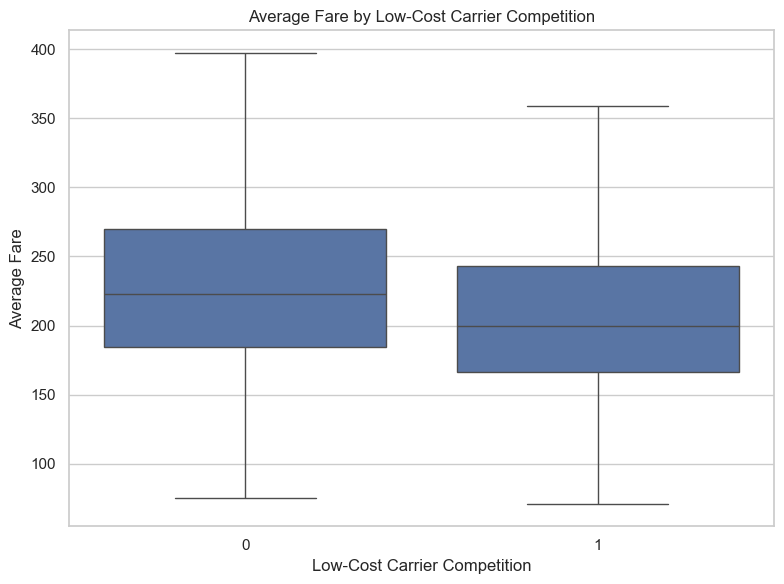

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=eda_sample,
    x="LCC_Comp",
    y=TARGET,
    showfliers=False,
    ax=ax,
)

ax.set_title("Average Fare by Low-Cost Carrier Competition")
ax.set_xlabel("Low-Cost Carrier Competition")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

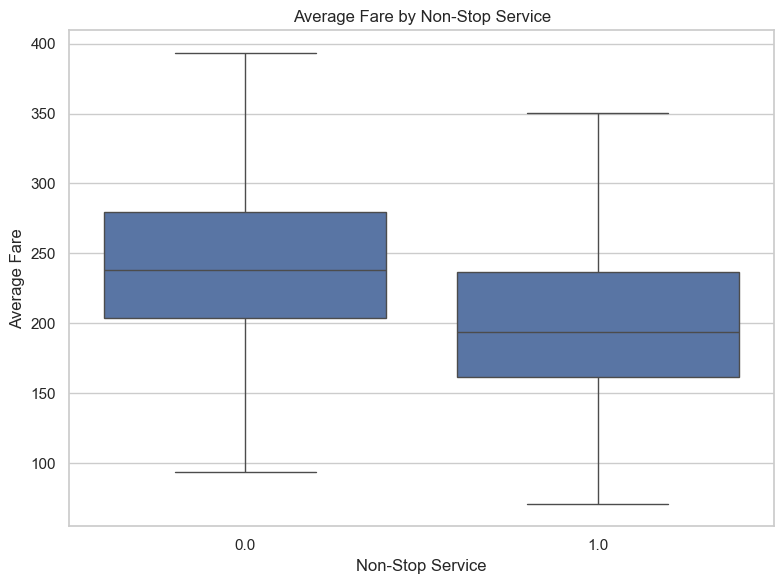

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=eda_sample,
    x="Non_Stop",
    y=TARGET,
    showfliers=False,
    ax=ax,
)

ax.set_title("Average Fare by Non-Stop Service")
ax.set_xlabel("Non-Stop Service")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

## Exploratory Analysis Summary

The exploratory analysis identifies several patterns relevant to the subsequent modeling stage:

- Average fares are strongly right-skewed and contain a substantial upper tail.
- Route distance has the strongest observed linear relationship with average fare, with both non-stop distance and market miles flown showing correlations of approximately 0.73.
- Market concentration and carrier market share show weaker but positive associations with average fares.
- Fare distributions also vary across market and service characteristics such as low-cost carrier competition and non-stop service.
- Several explanatory variables are related to one another, making regularized regression useful for evaluating linear relationships in the presence of correlated predictors.

These findings are descriptive and should not be interpreted as causal effects. The modeling stage therefore focuses on predictive performance and feature contribution rather than causal identification.

## 7. Modeling Strategy

The predictive analysis uses a reproducible sample of 200,000 observations. A common modeling sample and train-test split are used for all models so that their evaluation metrics are directly comparable.

Several columns in the dataset are encoded identifiers rather than continuous numerical variables. Treating values such as carrier, airport, or origin-destination IDs as ordinary numbers would impose artificial numerical relationships between categories.

The modeling strategy therefore:

- excludes raw city-market, airport, and origin-destination identifiers as numerical predictors;
- treats `Carrier` as a categorical feature;
- represents high-cardinality market, airport, and route identifiers using frequency encoding;
- fits frequency encodings using the training data only;
- uses the same training and test observations for every model;
- standardizes numerical features only for models that benefit from scaling.

The original frequency-encoded columns supplied with the dataset are recalculated from the training partition to avoid using information about the test-set distribution during preprocessing.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
CORE_NUMERIC_FEATURES = [
    "MktCoupons",
    "NonStopMiles",
    "RoundTrip",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "LCC_Comp",
    "Multi_Airport",
    "Circuity",
    "Slot",
    "Non_Stop",
    "MktMilesFlown",
]

FREQUENCY_ENCODING_MAP = {
    "OriginCityMarketID": "OriginCityMarketID_freq",
    "DestCityMarketID": "DestCityMarketID_freq",
    "OriginAirportID": "OriginAirportID_freq",
    "DestAirportID": "DestAirportID_freq",
    "ODPairID": "ODPairID_freq",
}

CATEGORICAL_FEATURES = [
    "Carrier",
]

FREQUENCY_FEATURES = list(FREQUENCY_ENCODING_MAP.values())

MODEL_NUMERIC_FEATURES = (
    CORE_NUMERIC_FEATURES
    + FREQUENCY_FEATURES
)

MODEL_FEATURES = (
    MODEL_NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

### Modeling Sample

The full dataset is retained for exploratory analysis. For model development, a fixed sample of 200,000 observations is used to keep ensemble-model training computationally practical while ensuring that every candidate model is evaluated on exactly the same observations.

In [24]:
modeling_sample = df.sample(
    n=min(MODELING_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE,
).copy()

train_df, test_df = train_test_split(
    modeling_sample,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Modeling sample: {len(modeling_sample):,} observations")
print(f"Training set:    {len(train_df):,} observations")
print(f"Test set:        {len(test_df):,} observations")

Modeling sample: 200,000 observations
Training set:    160,000 observations
Test set:        40,000 observations


### Frequency Encoding

High-cardinality identifiers are represented by their relative frequency in the training data.

For each identifier, the frequency mapping is estimated exclusively from the training partition and then applied to the test partition. An identifier that appears in the test data but not in the training data receives a frequency of zero.

The raw identifiers themselves are not supplied to the predictive models.

In [25]:
def apply_frequency_encoding(
    train_data,
    test_data,
    encoding_map,
):
    """Create train-fitted frequency-encoded features."""

    train_encoded = train_data.copy()
    test_encoded = test_data.copy()

    for source_column, encoded_column in encoding_map.items():
        frequency_map = (
            train_encoded[source_column]
            .value_counts(normalize=True)
        )

        train_encoded[encoded_column] = (
            train_encoded[source_column]
            .map(frequency_map)
        )

        test_encoded[encoded_column] = (
            test_encoded[source_column]
            .map(frequency_map)
            .fillna(0)
        )

    return train_encoded, test_encoded

In [26]:
train_df, test_df = apply_frequency_encoding(
    train_df,
    test_df,
    FREQUENCY_ENCODING_MAP,
)

In [27]:
X_train = train_df[MODEL_FEATURES].copy()
X_test = test_df[MODEL_FEATURES].copy()

y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

route_train = train_df["ODPairID"].copy()
route_test = test_df["ODPairID"].copy()

In [28]:
modeling_summary = pd.Series(
    {
        "Training observations": len(X_train),
        "Test observations": len(X_test),
        "Numerical features": len(MODEL_NUMERIC_FEATURES),
        "Categorical features": len(CATEGORICAL_FEATURES),
        "Missing values in X_train": int(X_train.isna().sum().sum()),
        "Missing values in X_test": int(X_test.isna().sum().sum()),
    },
    name="Value",
)

display(modeling_summary.to_frame())

,Value
Training observations,160000
Test observations,40000
Numerical features,18
Categorical features,1
Missing values in X_train,0
Missing values in X_test,0


In [29]:
assert X_train.index.intersection(X_test.index).empty
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

### Preprocessing Pipelines

Two preprocessing configurations are used while preserving the same underlying feature set.

For Linear, Ridge, and Lasso regression, numerical variables are standardized to zero mean and unit variance. This is particularly important for regularized regression because the penalty depends on coefficient magnitude.

For tree-based models, numerical variables are retained on their original scales because tree splitting is not sensitive to feature scaling.

In both cases, carrier codes are treated as categorical values and one-hot encoded rather than interpreted as numerical quantities.

In [30]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            MODEL_NUMERIC_FEATURES,
        ),
        (
            "carrier",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [31]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            MODEL_NUMERIC_FEATURES,
        ),
        (
            "carrier",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [32]:
feature_strategy = pd.DataFrame(
    {
        "Feature Group": [
            "Continuous / binary",
            "Frequency encoded",
            "Categorical",
            "Excluded raw identifiers",
        ],
        "Features": [
            ", ".join(CORE_NUMERIC_FEATURES),
            ", ".join(FREQUENCY_FEATURES),
            ", ".join(CATEGORICAL_FEATURES),
            ", ".join(
                [
                    "OriginCityMarketID",
                    "DestCityMarketID",
                    "OriginAirportID",
                    "DestAirportID",
                    "ODPairID",
                ]
            ),
        ],
    }
)

display(feature_strategy)

,Feature Group,Features
0,Continuous / binary,"MktCoupons, NonStopMiles, RoundTrip, Pax, Carr..."
1,Frequency encoded,"OriginCityMarketID_freq, DestCityMarketID_freq..."
2,Categorical,Carrier
3,Excluded raw identifiers,"OriginCityMarketID, DestCityMarketID, OriginAi..."


## 8. Baseline and Linear Models

The first modeling stage compares a simple mean-prediction baseline with three linear approaches:

- Linear Regression
- Ridge Regression
- Lasso Regression

The baseline provides a reference point for determining whether the explanatory variables add predictive value.

Linear Regression estimates an unregularized linear relationship between the predictors and average fare. Ridge and Lasso introduce regularization, which can reduce coefficient instability when predictors are correlated.

All models are trained and evaluated using the same training and test observations.

In [33]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [34]:
def evaluate_regression(model_name, y_true, y_pred):

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(
            y_true,
            y_pred,
        ) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

In [35]:
model_results = []

### 8.1 Baseline Model

A mean-prediction baseline is used as the minimum performance benchmark. The model predicts the mean fare observed in the training data for every test observation.

Any useful predictive model should materially outperform this benchmark.

In [36]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(
    X_train,
    y_train,
)

baseline_predictions = baseline_model.predict(X_test)

model_results.append(
    evaluate_regression(
        "Baseline",
        y_test,
        baseline_predictions,
    )
)

In [37]:
display(
    pd.DataFrame(model_results)
    .set_index("Model")
    .round(4)
)

,MAE,RMSE,R2
Model,,,
Baseline,51.7020,72.9521,-0.0000


### 8.2 Linear Regression

Linear Regression serves as the main interpretable statistical benchmark.

The preprocessing pipeline standardizes numerical predictors and one-hot encodes the carrier variable before fitting the model.

In [38]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_model.fit(
    X_train,
    y_train,
)

linear_predictions = linear_model.predict(X_test)

model_results.append(
    evaluate_regression(
        "Linear Regression",
        y_test,
        linear_predictions,
    )
)

### 8.3 Ridge Regression

Ridge Regression applies an L2 penalty to the regression coefficients. This can improve stability when predictors are correlated by discouraging excessively large coefficient values.

The initial model uses `alpha = 1.0`.

In [40]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("regressor", Ridge(alpha=1.0)),
    ]
)

ridge_model.fit(
    X_train,
    y_train,
)

ridge_predictions = ridge_model.predict(X_test)

model_results.append(
    evaluate_regression(
        "Ridge Regression",
        y_test,
        ridge_predictions,
    )
)

### 8.4 Lasso Regression

Lasso Regression applies an L1 penalty, which can shrink some coefficients toward zero and therefore provide a form of feature selection.

The initial model uses `alpha = 0.01`.

In [41]:
lasso_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("regressor", Lasso(
            alpha=0.01,
            max_iter=10_000,
        )),
    ]
)

lasso_model.fit(
    X_train,
    y_train,
)

lasso_predictions = lasso_model.predict(X_test)

model_results.append(
    evaluate_regression(
        "Lasso Regression",
        y_test,
        lasso_predictions,
    )
)

### Linear Model Comparison

In [42]:
linear_results = (
    pd.DataFrame(model_results)
    .set_index("Model")
    .sort_values("RMSE")
)

display(linear_results.round(4))

,MAE,RMSE,R2
Model,,,
Linear Regression,23.3823,35.5802,0.7621
Ridge Regression,23.3823,35.5803,0.7621
Lasso Regression,23.3846,35.5917,0.7620
Baseline,51.7020,72.9521,-0.0000


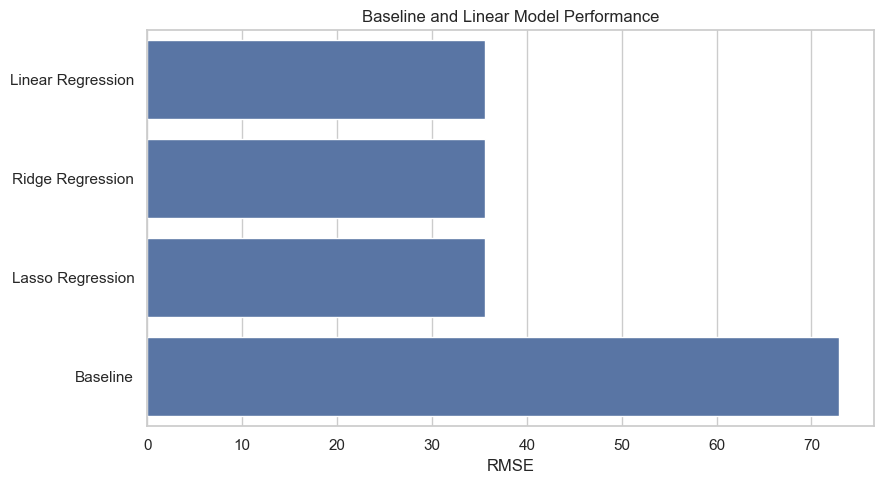

In [43]:
plot_data = (
    linear_results
    .reset_index()
    .sort_values("RMSE")
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=plot_data,
    x="RMSE",
    y="Model",
    ax=ax,
)

ax.set_title("Baseline and Linear Model Performance")
ax.set_xlabel("RMSE")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 8.5 Linear Regression Coefficients

Because numerical predictors are standardized before estimation, the numerical coefficients represent the expected change in predicted fare associated with a one-standard-deviation increase in the corresponding predictor, holding the other model features constant.

Carrier coefficients are relative to the one-hot encoded representation and should not be interpreted in the same way as continuous numerical coefficients.

The coefficients describe conditional associations within the predictive model and should not be interpreted as causal effects.

In [44]:
linear_feature_names = (
    linear_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

linear_coefficients = pd.DataFrame(
    {
        "Feature": linear_feature_names,
        "Coefficient": (
            linear_model
            .named_steps["regressor"]
            .coef_
        ),
    }
)

linear_coefficients["Absolute_Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

linear_coefficients = (
    linear_coefficients
    .sort_values(
        "Absolute_Coefficient",
        ascending=False,
    )
)

display(
    linear_coefficients[
        ["Feature", "Coefficient"]
    ]
    .head(15)
    .round(4)
)

,Feature,Coefficient
39,Carrier_21,-124.2882
26,Carrier_8,-122.7031
25,Carrier_7,-81.7565
31,Carrier_13,-78.4865
30,Carrier_12,-69.7544
1,NonStopMiles,65.4912
27,Carrier_9,61.3235
36,Carrier_18,-55.9279
34,Carrier_16,53.2397
23,Carrier_5,51.0584


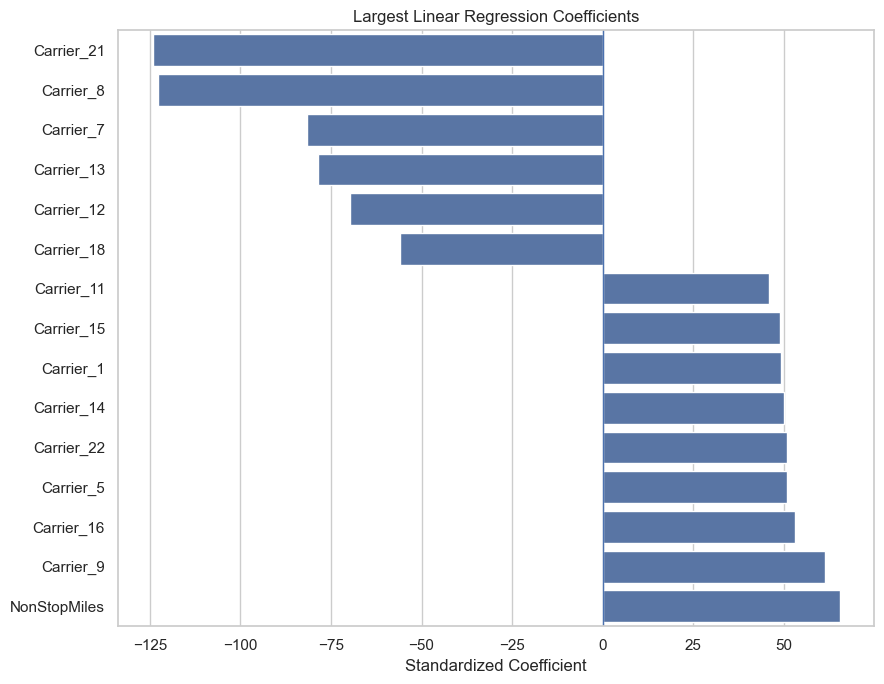

In [45]:
top_coefficients = (
    linear_coefficients
    .head(15)
    .sort_values("Coefficient")
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature",
    ax=ax,
)

ax.axvline(0, linewidth=1)
ax.set_title("Largest Linear Regression Coefficients")
ax.set_xlabel("Standardized Coefficient")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Linear Modeling Summary

All three linear specifications substantially outperform the mean-prediction baseline, indicating that the selected route, market, carrier, and competition variables contain meaningful predictive information.

The similarity between Linear, Ridge, and Lasso performance indicates whether regularization materially improves out-of-sample prediction under the selected feature representation.

The ensemble models introduced in the next section will test whether nonlinear relationships and interactions can capture additional structure that the linear models cannot represent.

## 9. Ensemble Models

Linear models assume that the relationship between the predictors and average fare can be represented through additive linear effects.

Airline pricing may instead involve nonlinear relationships and interactions among route distance, passenger demand, market concentration, carrier characteristics, and other factors.

Two tree-based ensemble methods are therefore evaluated:

- **Random Forest Regression**
- **Gradient Boosting Regression**

Both models use the same training and test observations as the linear models, allowing direct comparison of out-of-sample performance.

In [46]:
from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)

### 9.1 Random Forest Regression

Random Forest combines predictions from multiple decision trees fitted to different bootstrap samples and randomized subsets of features.

This allows the model to represent nonlinear relationships and interactions without requiring them to be specified manually.

The initial specification uses 100 trees with a maximum depth of 15, matching the configuration used in the original internship analysis.

In [47]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_model.fit(
    X_train,
    y_train,
)

rf_predictions = rf_model.predict(X_test)

model_results.append(
    evaluate_regression(
        "Random Forest",
        y_test,
        rf_predictions,
    )
)

### 9.2 Gradient Boosting Regression

Gradient Boosting builds decision trees sequentially, with each new tree attempting to reduce errors made by the existing ensemble.

Unlike Random Forest, which averages independently constructed trees, Gradient Boosting progressively improves a combined predictive model.

The initial specification uses 100 estimators, a learning rate of 0.1, and a maximum tree depth of 5.

In [48]:
gbr_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor),
        ),
        (
            "regressor",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=5,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

gbr_model.fit(
    X_train,
    y_train,
)

gbr_predictions = gbr_model.predict(X_test)

model_results.append(
    evaluate_regression(
        "Gradient Boosting",
        y_test,
        gbr_predictions,
    )
)

## 10. Model Performance Comparison

All six models are evaluated on the same held-out test set using three complementary metrics:

- **MAE (Mean Absolute Error):** average absolute prediction error;
- **RMSE (Root Mean Squared Error):** prediction error with greater sensitivity to large errors;
- **R² (Coefficient of Determination):** proportion of test-set variance explained by the model.

Lower MAE and RMSE indicate better predictive performance, while higher R² indicates better explanatory performance on unseen observations.

In [49]:
final_results = (
    pd.DataFrame(model_results)
    .drop_duplicates(
        subset="Model",
        keep="last",
    )
    .set_index("Model")
    .sort_values("RMSE")
)

display(final_results.round(4))

,MAE,RMSE,R2
Model,,,
Random Forest,6.8177,12.0763,0.9726
Gradient Boosting,15.7684,21.7481,0.9111
Linear Regression,23.3823,35.5802,0.7621
Ridge Regression,23.3823,35.5803,0.7621
Lasso Regression,23.3846,35.5917,0.7620
Baseline,51.7020,72.9521,-0.0000


In [50]:
assert len(final_results) == 6
assert final_results.index.is_unique

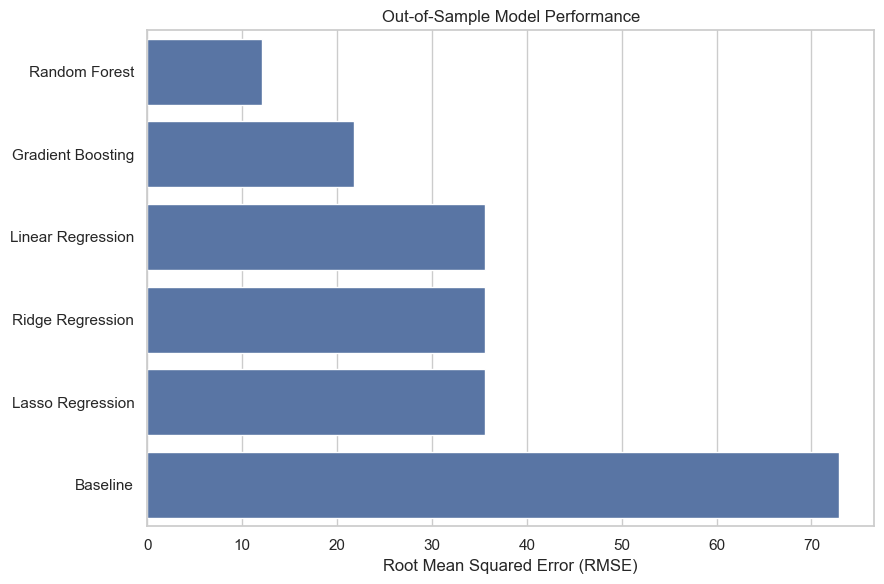

In [51]:
performance_plot = (
    final_results
    .reset_index()
    .sort_values("RMSE")
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=performance_plot,
    x="RMSE",
    y="Model",
    ax=ax,
)

ax.set_title("Out-of-Sample Model Performance")
ax.set_xlabel("Root Mean Squared Error (RMSE)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

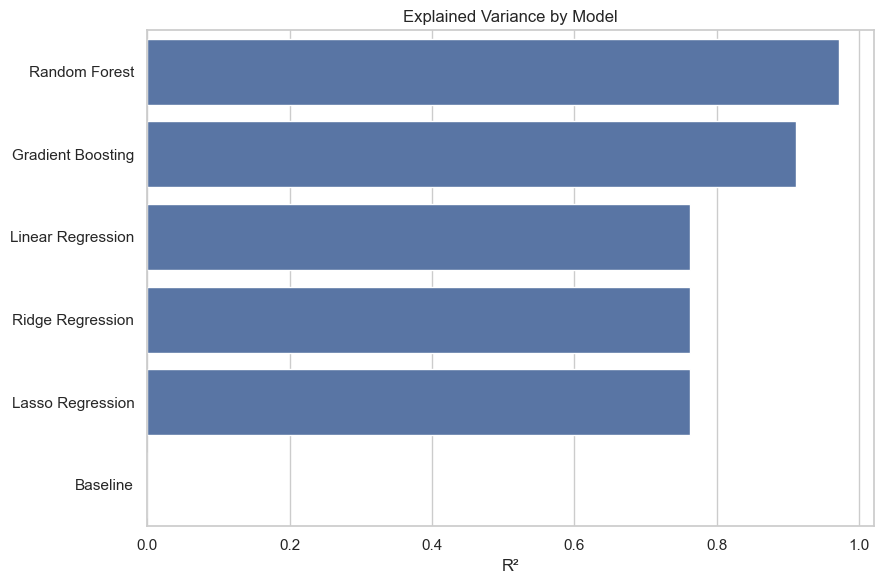

In [52]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=performance_plot.sort_values(
        "R2",
        ascending=False,
    ),
    x="R2",
    y="Model",
    ax=ax,
)

ax.set_title("Explained Variance by Model")
ax.set_xlabel("R²")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [53]:
best_model_name = final_results["RMSE"].idxmin()
best_model_metrics = final_results.loc[best_model_name]

print(f"Best model by RMSE: {best_model_name}")
display(
    best_model_metrics
    .rename("Value")
    .to_frame()
    .round(4)
)

Best model by RMSE: Random Forest


,Value
MAE,6.8177
RMSE,12.0763
R2,0.9726


In [54]:
baseline_rmse = final_results.loc["Baseline", "RMSE"]
best_rmse = best_model_metrics["RMSE"]

rmse_improvement = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
    * 100
)

print(
    "RMSE reduction relative to baseline: "
    f"{rmse_improvement:.1f}%"
)

RMSE reduction relative to baseline: 83.4%


### Performance Summary

The nonlinear ensemble models provide a direct test of whether interactions and nonlinear patterns improve fare prediction beyond the linear specifications.

The results show a clear difference in predictive performance across model classes. The best-performing specification substantially improves upon the mean baseline and the linear regression models, indicating that airline fare relationships contain structure that cannot be captured fully through additive linear effects alone.

The following sections examine the best-performing model in greater detail through feature importance and prediction-error diagnostics.

## 11. Model Interpretation and Diagnostics

Predictive performance alone does not explain how a model reaches its predictions or where it makes errors.

This section therefore examines:

- permutation feature importance on held-out observations;
- the relationship between actual and predicted fares;
- residual distributions;
- residual behavior across predicted fare levels;
- the magnitude of prediction errors.

The diagnostics focus on the best-performing model identified by test-set RMSE.

In [55]:
fitted_models = {
    "Baseline": baseline_model,
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbr_model,
}

model_predictions = {
    "Baseline": baseline_predictions,
    "Linear Regression": linear_predictions,
    "Ridge Regression": ridge_predictions,
    "Lasso Regression": lasso_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gbr_predictions,
}

best_model = fitted_models[best_model_name]
best_predictions = model_predictions[best_model_name]

print(f"Model selected for diagnostics: {best_model_name}")

Model selected for diagnostics: Random Forest


### 11.1 Permutation Feature Importance

Permutation importance evaluates a fitted model by randomly shuffling one predictor at a time while leaving the remaining test data unchanged.

If disrupting a feature causes a large reduction in predictive performance, the model depends strongly on that feature.

Unlike coefficients from a linear model, permutation importance does not indicate whether a feature increases or decreases predicted fares. It measures predictive contribution rather than direction or causality.

Importance is computed on held-out observations so that the analysis reflects out-of-sample predictive behavior.

In [56]:
from sklearn.inspection import permutation_importance

In [57]:
PERMUTATION_SAMPLE_SIZE = 10_000

permutation_sample = X_test.sample(
    n=min(PERMUTATION_SAMPLE_SIZE, len(X_test)),
    random_state=RANDOM_STATE,
)

permutation_target = y_test.loc[
    permutation_sample.index
]

In [58]:
permutation_result = permutation_importance(
    best_model,
    permutation_sample,
    permutation_target,
    scoring="r2",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [59]:
permutation_importance_df = (
    pd.DataFrame(
        {
            "Feature": permutation_sample.columns,
            "Importance_Mean": permutation_result.importances_mean,
            "Importance_SD": permutation_result.importances_std,
        }
    )
    .sort_values(
        "Importance_Mean",
        ascending=False,
    )
)

display(
    permutation_importance_df
    .head(15)
    .round(4)
)

,Feature,Importance_Mean,Importance_SD
12,MktMilesFlown,0.9911,0.0179
18,Carrier,0.3968,0.0132
1,NonStopMiles,0.2009,0.0072
5,Market_share,0.1236,0.0029
3,Pax,0.1230,0.0035
6,Market_HHI,0.0613,0.0017
9,Circuity,0.0462,0.0044
17,ODPairID_freq,0.0447,0.0049
4,CarrierPax,0.0364,0.0007
11,Non_Stop,0.0178,0.0018


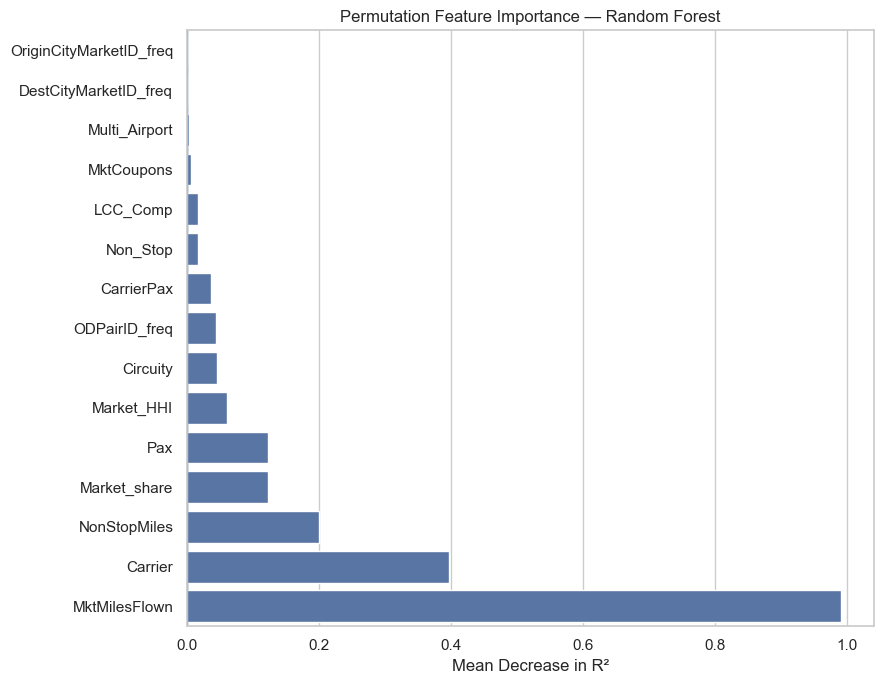

In [60]:
top_importance = (
    permutation_importance_df
    .head(15)
    .sort_values("Importance_Mean")
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    data=top_importance,
    x="Importance_Mean",
    y="Feature",
    ax=ax,
)

ax.axvline(0, linewidth=1)
ax.set_title(
    f"Permutation Feature Importance — {best_model_name}"
)
ax.set_xlabel("Mean Decrease in R²")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 11.2 Actual vs. Predicted Fares

A well-calibrated regression model should produce predictions that lie close to the 45-degree line where predicted fares equal observed fares.

A random subset of test observations is displayed to keep the visualization readable.

In [61]:
DIAGNOSTIC_SAMPLE_SIZE = 5_000

rng = np.random.default_rng(RANDOM_STATE)

diagnostic_indices = rng.choice(
    len(y_test),
    size=min(
        DIAGNOSTIC_SAMPLE_SIZE,
        len(y_test),
    ),
    replace=False,
)

actual_sample = y_test.iloc[
    diagnostic_indices
].to_numpy()

predicted_sample = best_predictions[
    diagnostic_indices
]

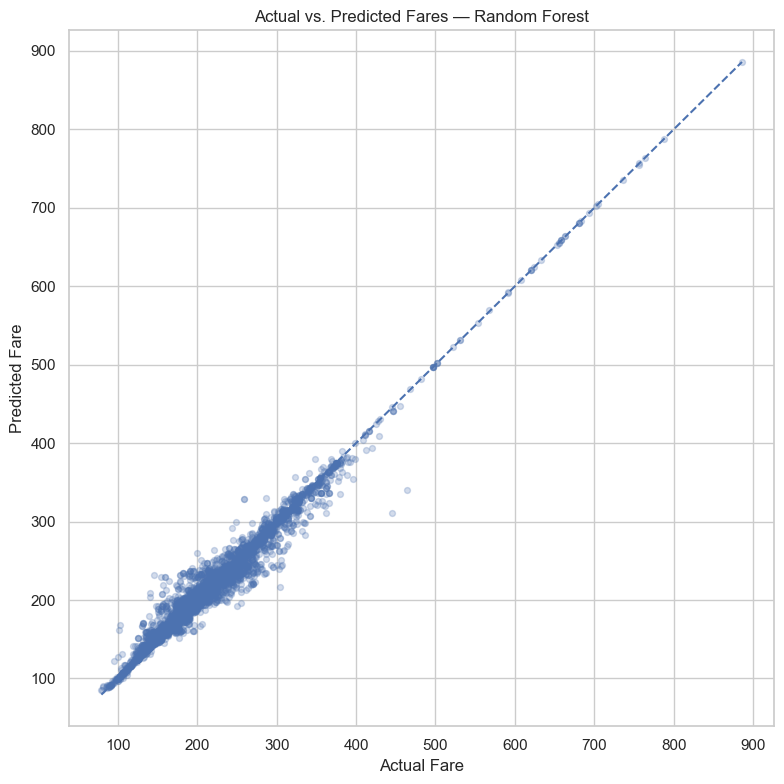

In [62]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    actual_sample,
    predicted_sample,
    alpha=0.25,
    s=18,
)

fare_min = min(
    actual_sample.min(),
    predicted_sample.min(),
)

fare_max = max(
    actual_sample.max(),
    predicted_sample.max(),
)

ax.plot(
    [fare_min, fare_max],
    [fare_min, fare_max],
    linestyle="--",
)

ax.set_title(
    f"Actual vs. Predicted Fares — {best_model_name}"
)
ax.set_xlabel("Actual Fare")
ax.set_ylabel("Predicted Fare")

plt.tight_layout()
plt.show()

### 11.3 Residual Analysis

Residuals are calculated as:

\[
\text{Residual} = \text{Actual Fare} - \text{Predicted Fare}
\]

A positive residual indicates that the model underpredicted the observed fare, while a negative residual indicates overprediction.

The residual distribution and its relationship with predicted fares are examined for systematic error patterns.

In [63]:
residuals = (
    y_test.to_numpy()
    - best_predictions
)

absolute_errors = np.abs(residuals)

In [64]:
residual_summary = pd.Series(
    {
        "Mean residual": residuals.mean(),
        "Median residual": np.median(residuals),
        "Residual SD": residuals.std(),
        "Mean absolute error": absolute_errors.mean(),
        "Median absolute error": np.median(absolute_errors),
        "90th percentile absolute error": np.quantile(
            absolute_errors,
            0.90,
        ),
        "95th percentile absolute error": np.quantile(
            absolute_errors,
            0.95,
        ),
    },
    name="Value",
)

display(
    residual_summary
    .to_frame()
    .round(4)
)

,Value
Mean residual,-0.1001
Median residual,-0.0000
Residual SD,12.0759
Mean absolute error,6.8177
Median absolute error,3.1724
90th percentile absolute error,18.1997
95th percentile absolute error,25.5347


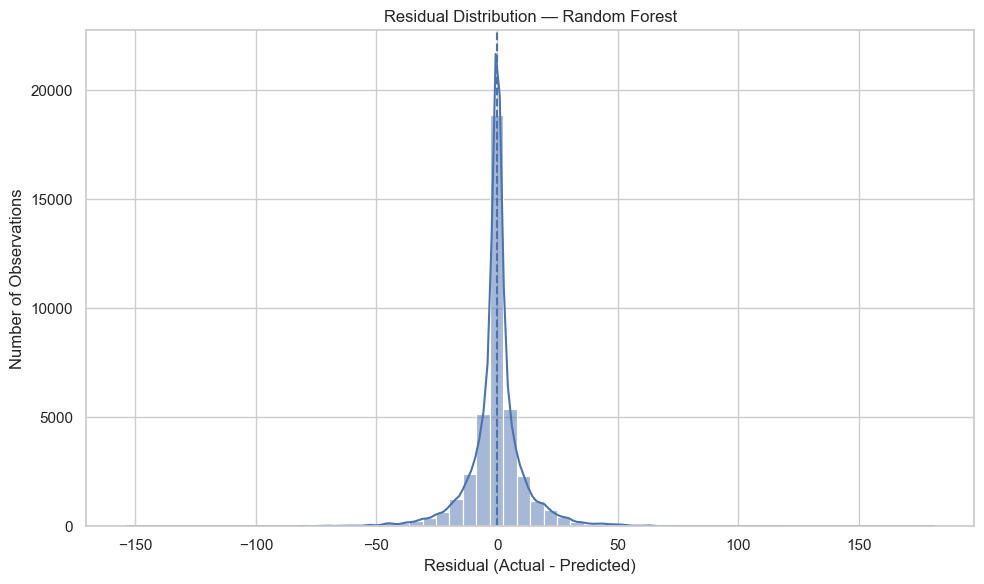

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=60,
    kde=True,
    ax=ax,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_title(
    f"Residual Distribution — {best_model_name}"
)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

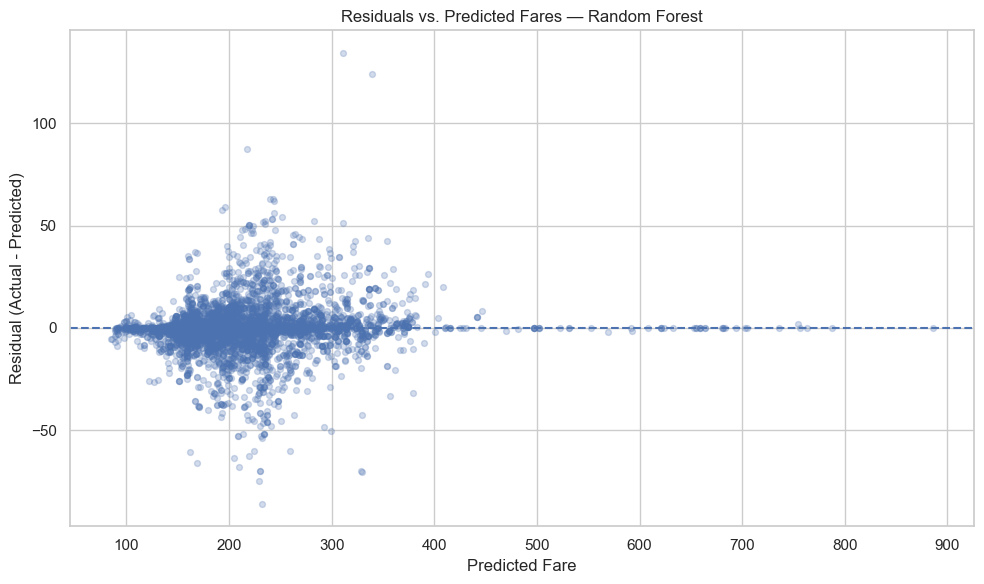

In [66]:
diagnostic_residuals = residuals[
    diagnostic_indices
]

diagnostic_predictions = best_predictions[
    diagnostic_indices
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    diagnostic_predictions,
    diagnostic_residuals,
    alpha=0.25,
    s=18,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_title(
    f"Residuals vs. Predicted Fares — {best_model_name}"
)
ax.set_xlabel("Predicted Fare")
ax.set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

### 11.4 Prediction Error by Fare Level

Because expensive fares are relatively uncommon and the target distribution is strongly right-skewed, aggregate error metrics may conceal differences in model performance across fare levels.

Test observations are therefore divided into fare quartiles and prediction errors are summarized within each group.

In [67]:
diagnostic_df = pd.DataFrame(
    {
        "Actual_Fare": y_test.to_numpy(),
        "Predicted_Fare": best_predictions,
        "Residual": residuals,
        "Absolute_Error": absolute_errors,
    }
)

diagnostic_df["Fare_Quartile"] = pd.qcut(
    diagnostic_df["Actual_Fare"],
    q=4,
    labels=[
        "Q1 — Lowest",
        "Q2",
        "Q3",
        "Q4 — Highest",
    ],
)

In [68]:
error_by_fare = (
    diagnostic_df
    .groupby(
        "Fare_Quartile",
        observed=True,
    )
    .agg(
        Observations=("Actual_Fare", "size"),
        Mean_Actual_Fare=("Actual_Fare", "mean"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean"),
    )
)

display(error_by_fare.round(2))

,Observations,Mean_Actual_Fare,MAE,Mean_Residual
Fare_Quartile,,,,
Q1 — Lowest,10009,143.4900,5.1500,-4.0300
Q2,10020,184.1700,6.4400,-2.3300
Q3,9982,223.1800,6.9100,0.5000
Q4 — Highest,9989,307.4500,8.7700,5.4800


### Interpretation Summary

Permutation importance identifies the predictors on which the selected model relies most strongly for out-of-sample fare prediction.

The diagnostic plots provide additional context beyond aggregate performance metrics. The actual-versus-predicted plot illustrates overall predictive agreement, while residual analysis reveals whether prediction errors are centered around zero and whether their magnitude changes across fare levels.

These importance measures and diagnostic patterns describe predictive behavior. They do not establish causal relationships between the explanatory variables and airline fares.

## 12. Robustness Analysis: Generalization to Unseen Routes

The primary model evaluation uses a random train-test split. Although appropriate for measuring predictive performance on unseen observations, a random split can place observations from the same origin-destination route in both the training and test sets.

This may produce optimistic estimates of generalization if a model learns route-specific patterns that are also represented in the test data.

A second, more restrictive validation strategy is therefore performed using `ODPairID` as a grouping variable. Entire routes are assigned either to the training set or to the test set, ensuring that no origin-destination pair appears in both partitions.

This experiment evaluates whether the best-performing model can generalize to routes that were completely unseen during training.

In [69]:
random_train_routes = set(
    route_train.unique()
)

random_test_routes = set(
    route_test.unique()
)

overlapping_routes = (
    random_train_routes
    .intersection(random_test_routes)
)

route_overlap_rate = (
    len(overlapping_routes)
    / len(random_test_routes)
)

test_rows_on_seen_routes = (
    route_test
    .isin(random_train_routes)
    .mean()
)

random_split_route_summary = pd.Series(
    {
        "Unique training routes": len(random_train_routes),
        "Unique test routes": len(random_test_routes),
        "Routes appearing in both sets": len(overlapping_routes),
        "Share of test routes also in training": route_overlap_rate,
        "Share of test rows on seen routes": test_rows_on_seen_routes,
    },
    name="Value",
)

display(
    random_split_route_summary
    .to_frame()
    .round(4)
)

,Value
Unique training routes,"5,186.0000"
Unique test routes,"4,356.0000"
Routes appearing in both sets,"4,318.0000"
Share of test routes also in training,0.9913
Share of test rows on seen routes,0.9988


The overlap statistics show how much route information is shared between the training and test partitions under random row-level sampling.

This does not constitute target leakage: test-set fares are never supplied to the model during training. However, substantial route overlap means that the random split primarily evaluates predictions for additional observations from routes that the model may already have encountered.

The following group-based split provides a stricter test of cross-route generalization.

In [70]:
from sklearn.model_selection import GroupShuffleSplit

In [71]:
route_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

route_train_idx, route_test_idx = next(
    route_splitter.split(
        modeling_sample,
        groups=modeling_sample["ODPairID"],
    )
)

route_holdout_train = (
    modeling_sample
    .iloc[route_train_idx]
    .copy()
)

route_holdout_test = (
    modeling_sample
    .iloc[route_test_idx]
    .copy()
)

In [72]:
route_holdout_train_routes = set(
    route_holdout_train["ODPairID"].unique()
)

route_holdout_test_routes = set(
    route_holdout_test["ODPairID"].unique()
)

assert route_holdout_train_routes.isdisjoint(
    route_holdout_test_routes
)

In [73]:
route_holdout_summary = pd.Series(
    {
        "Training observations": len(route_holdout_train),
        "Test observations": len(route_holdout_test),
        "Training routes": len(route_holdout_train_routes),
        "Test routes": len(route_holdout_test_routes),
        "Overlapping routes": len(
            route_holdout_train_routes
            .intersection(route_holdout_test_routes)
        ),
    },
    name="Value",
)

display(
    route_holdout_summary.to_frame()
)

,Value
Training observations,159183
Test observations,40817
Training routes,4179
Test routes,1045
Overlapping routes,0


### Train-Fitted Encoding for the Route Holdout

Frequency encodings are recalculated using only the route-holdout training partition.

This ensures that information about the distribution of identifiers in the unseen-route test partition is not incorporated during preprocessing.

In [74]:
route_holdout_train, route_holdout_test = (
    apply_frequency_encoding(
        route_holdout_train,
        route_holdout_test,
        FREQUENCY_ENCODING_MAP,
    )
)

In [75]:
X_route_train = (
    route_holdout_train[
        MODEL_FEATURES
    ]
    .copy()
)

X_route_test = (
    route_holdout_test[
        MODEL_FEATURES
    ]
    .copy()
)

y_route_train = (
    route_holdout_train[TARGET]
    .copy()
)

y_route_test = (
    route_holdout_test[TARGET]
    .copy()
)

In [76]:
assert X_route_train.isna().sum().sum() == 0
assert X_route_test.isna().sum().sum() == 0
assert len(X_route_train) == len(y_route_train)
assert len(X_route_test) == len(y_route_test)

### Route-Holdout Baseline

A new mean baseline is fitted using only the route-holdout training partition. This provides an appropriate reference for the more restrictive validation experiment.

In [77]:
route_baseline_model = DummyRegressor(
    strategy="mean"
)

route_baseline_model.fit(
    X_route_train,
    y_route_train,
)

route_baseline_predictions = (
    route_baseline_model
    .predict(X_route_test)
)

route_baseline_result = evaluate_regression(
    "Route Holdout Baseline",
    y_route_test,
    route_baseline_predictions,
)

### Best Model on Unseen Routes

The model architecture that achieved the lowest RMSE under random validation is retrained from scratch using the route-grouped training partition.

No parameters fitted during the original random split are reused.

In [78]:
route_holdout_model = clone(
    fitted_models[best_model_name]
)

route_holdout_model.fit(
    X_route_train,
    y_route_train,
)

route_holdout_predictions = (
    route_holdout_model
    .predict(X_route_test)
)

route_holdout_result = evaluate_regression(
    best_model_name,
    y_route_test,
    route_holdout_predictions,
)

In [79]:
random_split_result = {
    "Validation": "Random Row Split",
    "Model": best_model_name,
    "MAE": final_results.loc[
        best_model_name,
        "MAE",
    ],
    "RMSE": final_results.loc[
        best_model_name,
        "RMSE",
    ],
    "R2": final_results.loc[
        best_model_name,
        "R2",
    ],
}

route_model_result = {
    "Validation": "Unseen Route Holdout",
    **route_holdout_result,
}

route_baseline_comparison = {
    "Validation": "Unseen Route Holdout",
    **route_baseline_result,
}

robustness_results = pd.DataFrame(
    [
        random_split_result,
        route_model_result,
        route_baseline_comparison,
    ]
)

display(
    robustness_results
    .set_index(
        ["Validation", "Model"]
    )
    .round(4)
)

MAE    RMSE      R2
Validation           Model                                         
Random Row Split     Random Forest           6.8177 12.0763  0.9726
Unseen Route Holdout Random Forest          25.5090 48.0128  0.6433
                     Route Holdout Baseline 55.0956 80.9450 -0.0138

In [80]:
random_rmse = final_results.loc[
    best_model_name,
    "RMSE",
]

route_holdout_rmse = (
    route_holdout_result["RMSE"]
)

rmse_change_pct = (
    (
        route_holdout_rmse
        - random_rmse
    )
    / random_rmse
    * 100
)

random_r2 = final_results.loc[
    best_model_name,
    "R2",
]

route_holdout_r2 = (
    route_holdout_result["R2"]
)

print(
    "RMSE change under unseen-route validation: "
    f"{rmse_change_pct:+.1f}%"
)

print(
    "R² change under unseen-route validation: "
    f"{route_holdout_r2 - random_r2:+.4f}"
)

RMSE change under unseen-route validation: +297.6%
R² change under unseen-route validation: -0.3293


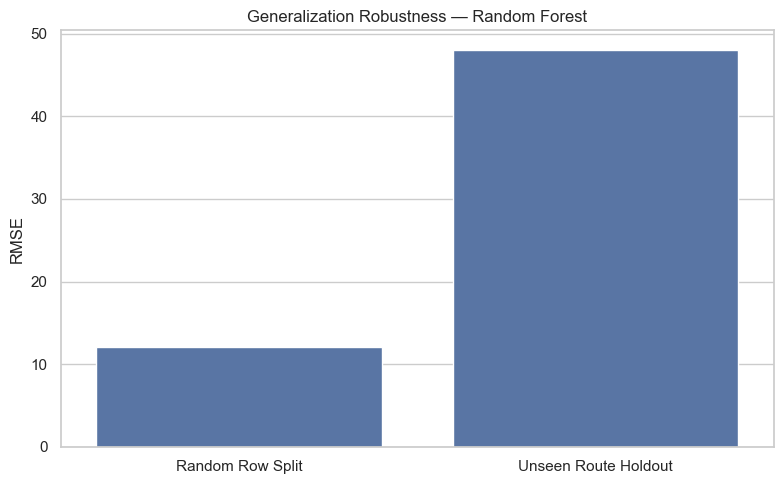

In [81]:
validation_plot = pd.DataFrame(
    {
        "Validation": [
            "Random Row Split",
            "Unseen Route Holdout",
        ],
        "RMSE": [
            random_rmse,
            route_holdout_rmse,
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=validation_plot,
    x="Validation",
    y="RMSE",
    ax=ax,
)

ax.set_title(
    f"Generalization Robustness — {best_model_name}"
)
ax.set_xlabel("")
ax.set_ylabel("RMSE")

plt.tight_layout()
plt.show()

### Robustness Interpretation

The route-aware validation provides a substantially stricter test than the standard random split because every origin-destination pair in the test set is absent from the training data.

Any deterioration in performance therefore quantifies the additional difficulty of generalizing to previously unseen routes rather than predicting new observations for routes already represented during training.

The experiment also demonstrates that predictive performance should be interpreted in relation to the intended deployment scenario. Random-split performance is relevant when predicting additional observations within an existing route network, whereas the route-holdout experiment is more informative for generalization to new markets.

These results remain predictive rather than causal.